In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [51]:
estaciones_sel = pd.read_csv("../export/estaciones-seleccionadas.csv")
extraccion = pd.read_csv("../export/extraccion_20260821-090338.csv", sep=";", low_memory=False)

print(estaciones_sel.shape, extraccion.shape)
estaciones_sel.head()

(383, 10) (6285, 35)


,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales


In [52]:
extraccion.head()

,id_muestra,nro_muestra,nombre_programa,id_programa,cue_nombre,id_cuenca,sub_cue_nombre,id_sub_cuenca,estacion,id_estacion,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,3255642,23951,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,90,XSLH030.S,100201,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,3.6,NaN,NaN,3.6
1,3255643,23952,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,160,EPSE020.S,100232,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,7.1,NaN,NaN,7.1
2,3255644,23953,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,159,EPSE030.S,100230,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,1.5,NaN,NaN,1.5
3,3255645,23954,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,160,EPSE040.S,100231,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,3.3,NaN,NaN,3.3
4,3255651,23966,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA hasta Río Santa Lucía Chico,84,XVIR050.S,100304,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,0.9,NaN,NaN,0.9


In [54]:
extraccion_chl_a = extraccion[extraccion["param"] == "Clo_a"]

In [55]:
extraccion_chl_a.shape

(6285, 35)

In [56]:
sel_ids = set(estaciones_sel["id_estacion"])
ext_ids = set(extraccion["id_estacion"])

In [58]:
estaciones_gdf = gpd.GeoDataFrame(
    estaciones_sel,
    geometry=gpd.points_from_xy(estaciones_sel["longitud"], estaciones_sel["latitud"]),
    crs="EPSG:4326",
)
estaciones_gdf.head()

,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz,geometry
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.41304 -32.9058)
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.26189 -33.24894)
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.4464 -32.53375)
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales,POINT (-54.76897 -33.82949)
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.65108 -33.1584)


In [59]:
type(estaciones_gdf)

geopandas.geodataframe.GeoDataFrame

In [60]:
OAN_registros = estaciones_gdf.merge(extraccion,
                                          left_on = "id_estacion",
                                          right_on ="id_estacion",
                                          how = "left"
                                          )#.drop(columns=["id_estacion"])

OAN_registros.head()


,nombre_programa_x,id_programa_x,estacion_x,id_estacion,latitud,longitud,id_tipo_punto_x,tip_pun_est_descripcion_x,id_matriz_x,nombre_matriz,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27.0,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27.0,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27.0,µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27.0,µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27.0,µg/L,2.600000000,0.700000000,2.2,2.600000000


In [61]:
OAN_registros.shape

(6457, 45)

In [62]:
type(OAN_registros)

geopandas.geodataframe.GeoDataFrame

In [63]:
OAN_registros.to_file("../export/joins/OAN_registros.geojson", driver="GeoJSON")

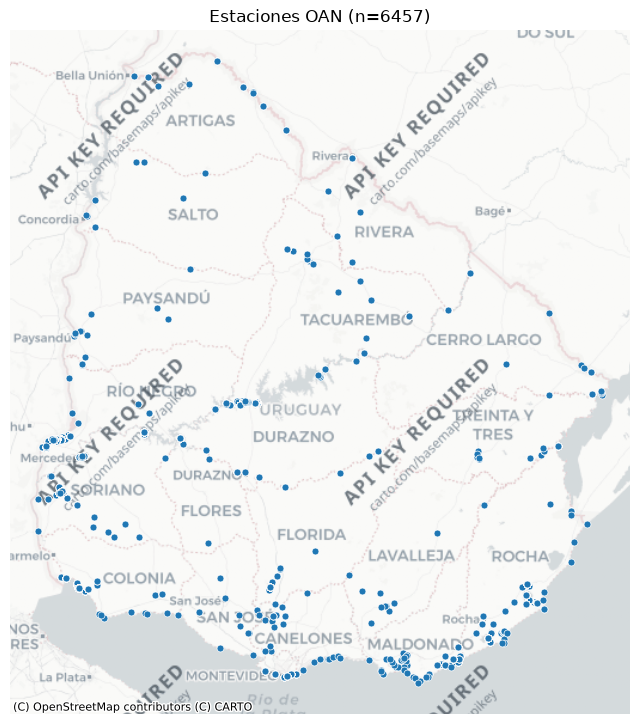

In [64]:
gdf_mapa = OAN_registros.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
gdf_mapa.plot(ax=ax, markersize=25, color="tab:blue", edgecolor="white", linewidth=0.5)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Estaciones OAN (n={len(gdf_mapa)})")
plt.show()